### 8.2

Fitted parameters: Ie = 1201.24, re = 4.00, n = 2.00


/tmp/ipykernel_556144/1503216226.py:39: RuntimeWarning: invalid value encountered in power
  return Ie * np.exp((-bn) * ((r / re) ** n - 1)) # Logical error


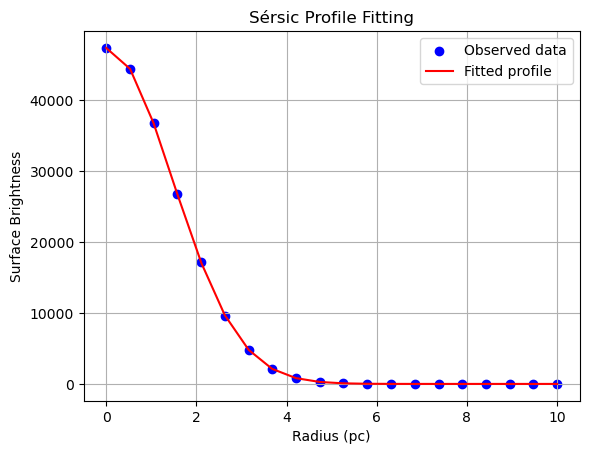

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = [
  0.00,  47373.98,
  0.53,  44447.19,
  1.05,  36728.40,
  1.58,  26730.46,
  2.11,  17122.92,
  2.63,  9643.88,
  3.16,  4806.90,
  3.68,  2109.92,
  4.21,  793.68,
  4.74,  289.23,
  5.26,  93.78,
  5.79,  32.29,
  6.32,  14.18,
  6.84,  3.27,
  7.37,  5.26,
  7.89,  2.89,
  8.42,  1.83,
  8.95,  0.82,
  9.47,  0.61,
  10.00, 0.93
]


radii, brightness = data[0::2], data[1::2]  # Not the right slicing, is a logical error


def sersic_profile(r, Ie, re, n):  # Contains two RuntimeWarnings, but these errors don't negatively affect the code. Fitting is still right.
    """
    Sérsic profile:
    I(r) = Ie * exp(-bn * ((r/re)^n - 1))
    bn can be approximated as 2n - 0.324
    """
    bn = 2 * n - 0.324  # Missing "- 0.324" which is stated in the excercise, logical error
    return Ie * np.exp((-bn) * ((r / re) ** n - 1)) # Logical error

popt, pcov = curve_fit(sersic_profile, radii, brightness, p0 = [5000, 10, 4])  # RunTimeError, missing some arguments, added radii and brightness

Ie_fit, re_fit, n_fit = popt  # RunTime error, missing n_fit

print(f"Fitted parameters: Ie = {Ie_fit:.2f}, re = {re_fit:.2f}, n = {n_fit:.2f}")  # No f-string, which is an SyntaxError

fig, ax = plt.subplots()
ax.scatter(radii, brightness, color='blue', label='Observed data')  # RunTimeError, can't use fig, have to use ax
ax.plot(radii, sersic_profile(radii, Ie_fit, re_fit, n_fit), color='red', label='Fitted profile')  # SyntaxError, bracket never closed / # TypeError, bracket missing between n_fit and color
ax.set_xlabel("Radius (pc)")
ax.set_ylabel("Surface Brightness")
ax.set_title("Sérsic Profile Fitting")
ax.legend()
ax.grid()
plt.show()


